In [12]:

from asyncio import Event
import json
from operator import index
from msilib import Table
import streamlit as st
import pandas
import pandas as pd
import numpy as np
import os
import csv
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from tqdm import tqdm
from typing import Iterable, Tuple, List, Set, Dict, Optional, Literal
from collections import Counter
from pathlib import Path
from git import Repo, exc as git_exc
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
import random

from torch.utils.data import Dataset, DataLoader

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from dataclasses import dataclass
from github import Github, GithubException, UnknownObjectException, IncompletableObject
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, recall_score, classification_report, confusion_matrix


C:\Users\samut\AppData\Local\Temp\ipykernel_43156\3920976770.py:4: DeprecationWarning: 'msilib' is deprecated and slated for removal in Python 3.13
  from msilib import Table


In [13]:
file_path = r"D:\Users\samut\OneDrive\Documents\GitHub\developersInactivityAnalysisCOPY\Extractors\THIS_FILE.csv"


df= pd.read_csv(file_path)
df

,Unnamed: 0,dev,date,coding_day,nc_day,break_day,th,len,index,state,...,pr_activity,coding_total,noncoding_total,commits_log,prs_log,issues_log,issue_activity_log,pr_activity_log,activity_log,non_coding_log
0,1287,MDQ6VXNlcjk1ODI=,2011-11-27,2.052285,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,6,3,6,1.386294,0.0,0.0,0.0,1.945910,1.386294,1.945910
1,1288,MDQ6VXNlcjk1ODI=,2011-11-28,2.052285,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,11,6,11,1.945910,0.0,0.0,0.0,2.484907,1.945910,2.484907
2,1289,MDQ6VXNlcjk1ODI=,2011-11-29,2.052285,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,5,1,5,0.693147,0.0,0.0,0.0,1.791759,0.693147,1.791759
3,1290,MDQ6VXNlcjk1ODI=,2011-11-30,2.052285,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,7,7,7,2.079442,0.0,0.0,0.0,2.079442,2.079442,2.079442
4,1291,MDQ6VXNlcjk1ODI=,2011-12-01,2.052285,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,1,10,1,2.397895,0.0,0.0,0.0,0.693147,2.397895,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2378,MDQ6VXNlcjk1ODI=,2014-11-22,-0.487262,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1092,2379,MDQ6VXNlcjk1ODI=,2014-11-23,-0.487262,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1093,2380,MDQ6VXNlcjk1ODI=,2014-11-24,-0.487262,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1094,2381,MDQ6VXNlcjk1ODI=,2014-11-25,-0.487262,-0.337187,0,0.0,0.0,0.0,ACTIVE,...,0,0,0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000


TypeError: can only concatenate str (not "numpy.timedelta64") to str

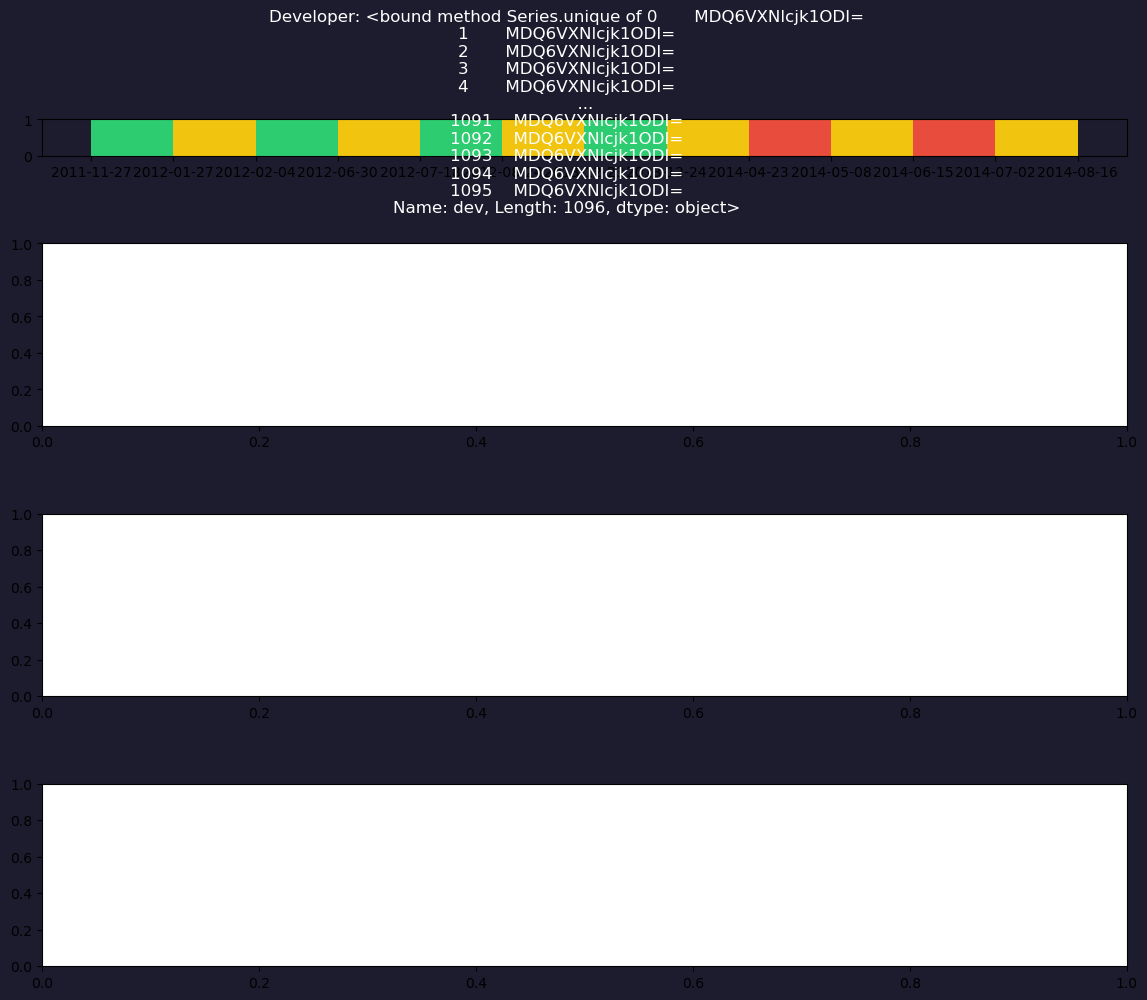

In [18]:
_STATE_COLORS = {
    "ACTIVE":     "#2ecc71",   # green
    "NON_CODING": "#f1c40f",   # yellow
    "INACTIVE":   "#e74c3c",   # red
    "GONE":       "#95a5a6",   # grey
    "UNKNOWN":    "#bdc3c7",   # light grey
}

def _shade_states(ax, df, date_col, state_col, alpha=0.3):
    """Shade axis background by state, grouping consecutive equal-state rows."""
    if df.empty:
        return
    dates  = df[date_col].values
    states = df[state_col].values
    i = 0
    while i < len(states):
        j = i + 1
        while j < len(states) and states[j] == states[i]:
            j += 1
        color = _STATE_COLORS.get(str(states[i]), "#7f8c8d")
        end   = dates[j] if j < len(dates) else dates[-1] + np.timedelta64(2, "D")
        ax.axvspan(dates[i], end, color=color, alpha=alpha, zorder=1, linewidth=0)
        i = j

def make_state_graph_2(df):
    import matplotlib.patches as mpatches

    dev = df["dev"].unique
    has_probs = True
    wdf = df
    wdf_w = df
    BG = "#1c1c2e"

    # ── figure layout: 3 panels always, 4th only if prob cols exist ───────────
    n_panels     = 4 if has_probs else 3
    height_ratios = [0.4, 2, 2, 2] if has_probs else [0.4, 2, 2]

    fig, axes = plt.subplots(
        n_panels, 1, figsize=(14, 11 if has_probs else 9),
        facecolor=BG,
        gridspec_kw={"height_ratios": height_ratios},
    )
    fig.suptitle(f"Developer: {dev}", color="white", fontsize=12)
    fig.subplots_adjust(hspace=0.6)

    # Panel 0 – full timeline strip
    ax0 = axes[0]
    ax0.set_facecolor(BG)
    _shade_states(ax0, wdf, "date", "state", alpha=1.0)
    ax0.axvspan(win_start, win_end, color="black", alpha=0.5, zorder=2)
    ax0.set_xlim(min_date, max_date)
    ax0.set_yticks([])
    ax0.set_title("Full timeline  (white band = current window)", color="white", fontsize=9, pad=4)
    ax0.tick_params(colors="white", labelsize=8)
    ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax0.xaxis.set_major_locator(mdates.YearLocator())
    for sp in ax0.spines.values():
        sp.set_visible(False)

    # Panel 1 – coding activity
    ax1 = axes[1]
    ax1.set_facecolor(BG)
    _shade_states(ax1, wdf_w, "date", "state", alpha=0.25)
    active = wdf_w[wdf_w["activity_log"] > 0]
    if not active.empty:
        ax1.bar(active["date"], active["commits_log"], width=1, color="Green", alpha=0.9, zorder=3)
        ax1.bar(active["date"], active["prs_log"],     width=1, color="Yellow", alpha=0.9, zorder=3)
    ax1.set_xlim(win_start, win_end)
    ax1.set_ylabel("log(commits + PRs)", color="white", fontsize=9)
    ax1.set_title("Coding Activity", color="white", fontsize=10, pad=4)
    ax1.tick_params(colors="white", labelsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.legend(["commits_log", "prs_log"], loc="upper left", facecolor=BG, labelcolor="white", fontsize=8, framealpha=0)
    plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")
    for sp in ax1.spines.values():
        sp.set_color("#444")

    # Panel 2 – non-coding activity
    ax2 = axes[2]
    ax2.set_facecolor(BG)
    _shade_states(ax2, wdf_w, "date", "state", alpha=0.25)
    nc = wdf_w[wdf_w["non_coding_log"] > 0]
    #wdf["issues_log"]      = np.log1p(wdf["issues"])
    #wdf["issue_activity_log"] = np.log1p(wdf["issue_activity"])
    #wdf["pr_activity_log"] = np.log1p(wdf["pr_activity"])
    if not nc.empty:
        ax2.bar(nc["date"], nc["issues_log"], width=1, color="red", alpha=0.9, zorder=3)
        ax2.bar(nc["date"], nc["issue_activity_log"], width=1, color="red", alpha=0.9, zorder=3)
        ax2.bar(nc["date"], nc["pr_activity_log"], width=1, color="yellow", alpha=0.9, zorder=3)

    ax2.set_xlim(win_start, win_end)
    ax2.set_ylabel("log(issues + comments)", color="white", fontsize=9)
    ax2.set_title("Non-Coding Activity", color="white", fontsize=10, pad=4)
    ax2.tick_params(colors="white", labelsize=8)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax2.legend(["issues_log", "issue_activity_log", "pr_activity_log"], loc="upper left", facecolor=BG, labelcolor="white", fontsize=8, framealpha=0)
    plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")
    for sp in ax2.spines.values():
        sp.set_color("#444")

    # Panel 3 – predicted state probabilities (only if prob cols exist) ────────
    if has_probs:
        ax3 = axes[3]
        ax3.set_facecolor(BG)

        # filter to window rows that actually have predictions
        prob_w = wdf_w.dropna(subset=prob_cols).sort_values("date")
        prob_w.to_csv("THIS_FILE.csv")

        #we have break_starts_in_14d and prob_0
        # prob_0 is the models yhat this is the reponces
        # the break_starts_in_14d in the true y value
        # we need to plot both of these

        # Detect binary (survival) vs multi-class (shifted_state) predictions
        is_binary = sorted(prob_cols) == ["prob_0", "prob_1"]

        if not prob_w.empty:
            if is_binary:
                # Binary mode: two line plots — P(not active) and P(active)
                ax3.plot(prob_w["date"], prob_w["prob_1"],
                        color="#e67e22", linewidth=1.5,
                        label="P(break starts in 14d)")
                ax3.plot(prob_w["date"], prob_w["break_starts_in_14d"].astype(float),
                        color="#2ecc71", linewidth=1.5,
                        label="True break in 14d")
                #ax3.plot(prob_w["date"], prob_w["prob_1"],
                #         color="#2ecc71", linewidth=1.5,
                #         label="P(active in 14d)")

                ax3.axhline(0.5, color="white", linestyle="--",
                            linewidth=0.8, alpha=0.5)
                ax3.legend(loc="upper left", facecolor=BG, labelcolor="white",
                           fontsize=8, framealpha=0)
            else:
                # Multi-class mode: stacked area chart
                palette_mc = [_STATE_COLORS.get(cl.replace("prob_", ""), "#888888")
                              for cl in prob_cols]
                dates       = prob_w["date"].values
                prob_matrix = prob_w[prob_cols].values
                class_labels = [c.replace("prob_", "") for c in prob_cols]
                ax3.stackplot(dates, prob_matrix.T, labels=class_labels,
                              colors=palette_mc, alpha=0.25)
                ax3.legend(loc="upper left", facecolor=BG, labelcolor="white",
                           fontsize=8, framealpha=0)
        else:
            ax3.text(0.5, 0.5, "No predictions in this window",
                     ha="center", va="center", color="white",
                     transform=ax3.transAxes, fontsize=9)

        ax3.set_xlim(win_start, win_end)
        ax3.set_ylim(0, 1)
        ax3.set_ylabel("Probability", color="white", fontsize=9)
        _title = ("Transition Probability  (LSTM — binary survival)"
                  if is_binary else "Predicted State Probabilities  (LSTM)")
        ax3.set_title(_title, color="white", fontsize=10, pad=4)
        ax3.tick_params(colors="white", labelsize=8)
        ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax3.get_xticklabels(), rotation=30, ha="right")
        for sp in ax3.spines.values():
            sp.set_color("#444")

    # legend for state colours
    patches = [mpatches.Patch(color=c, label=s) for s, c in _STATE_COLORS.items()]
    fig.legend(handles=patches, loc="upper right", ncol=5,
               facecolor=BG, labelcolor="white", fontsize=8, framealpha=0)

    st.pyplot(fig)
    plt.close(fig)


make_state_graph_2(df)